In [29]:
import geopandas as gpd
from shapely import wkt
from shapely import Point
import pandas as pd
import numpy as np

# Selecionando dataset
## Linhas
Já temos um dataset criado, chamado linhas.pkl, que tem apenas 600 linhas, enquanto o dataset original tem mais de 1700. No entanto, como será demonstrado, apenas o de 600 é suficiente para ligar as cisps entre si 

### Acessando o dataset pesado (i.e, com muitas linhas)

In [30]:
aux = pd.read_csv("../datasets/shapes_geom.csv")
aux = aux.drop_duplicates(subset=["shape_id"])
aux

,feed_version,feed_start_date,feed_end_date,shape_id,shape,shape_distance,start_pt,end_pt,versao_modelo
0,2023-12-16,2023-12-16,2023-12-20,1oge,"LINESTRING(-43.232036 -22.923777, -43.23146 -2...",24466.1,POINT(-43.232036 -22.923777),POINT(-43.36544 -23.0016),201d79faee763526a030ff998bebea9782efe961
1,2025-06-01,2025-06-01,2025-07-15,9ptt,"MULTILINESTRING((-43.29031 -22.90076, -43.2902...",17517.0,POINT(-43.29031 -22.90076),POINT(-43.17068 -22.90907),02716ed5a495ae53c1c4948184b5d093aa3126a8
2,2025-11-08,2025-11-08,2025-11-18,35bu,"MULTILINESTRING((-43.17754 -22.90107, -43.1775...",33079.0,POINT(-43.17754 -22.90107),POINT(-43.39397 -22.95665),2a53b9c61f4b76fe07761a33083c714f9c35bcd0
3,2025-10-04,2025-10-04,2025-10-11,iz18,"LINESTRING(-43.19987 -22.93997, -43.19975 -22....",12591.1,POINT(-43.19987 -22.93997),POINT(-43.2238 -22.98097),40c2bc268bdc2e22bc2474d99bca38dcb9ea4c40
4,2024-03-11,2024-03-11,2024-03-17,2ibq,"LINESTRING(-43.621884 -22.968783, -43.62189 -2...",24430.2,POINT(-43.621884 -22.968783),POINT(-43.4637 -22.87668),201d79faee763526a030ff998bebea9782efe961
...,...,...,...,...,...,...,...,...,...
13776,2023-03-01,2023-03-01,2023-03-15,krez,"MULTILINESTRING((-43.36332 -22.80502, -43.3638...",28149.7,POINT(-43.36332 -22.80502),POINT(-43.2753 -22.90216),201d79faee763526a030ff998bebea9782efe961
13868,2023-03-01,2023-03-01,2023-03-15,n6x6,"LINESTRING(-43.18086 -22.90192, -43.1791 -22.9...",23999.8,POINT(-43.18086 -22.90192),POINT(-43.342379 -22.872688),201d79faee763526a030ff998bebea9782efe961
13877,2026-03-14,2026-03-14,2026-03-27,gzrt,"MULTILINESTRING((-43.22883 -22.88588, -43.2281...",18883.0,POINT(-43.22883 -22.88588),POINT(-43.22304 -22.98473),3a6c7f1b4d7d9c5cc07568b119f9e07d65ab5cb7
13927,2023-06-01,2023-06-01,2023-06-15,u9o7_0,"LINESTRING(-43.18829 -22.91698, -43.18825 -22....",5900.6,POINT(-43.18829 -22.91698),POINT(-43.18422 -22.90219),201d79faee763526a030ff998bebea9782efe961


In [31]:
def carregar_wkt(texto):
    try:
        return wkt.loads(texto)
    except:
        return None

In [32]:
aux['shape'] = aux['shape'].apply(carregar_wkt)
aux = aux.drop(["feed_version", "feed_start_date", "feed_end_date", "start_pt", "end_pt", "versao_modelo"], axis=1)

In [33]:
aux.drop_duplicates(["shape", "shape_id"])

,shape_id,shape,shape_distance
0,1oge,"LINESTRING (-43.232036 -22.923777, -43.23146 -...",24466.1
1,9ptt,"MULTILINESTRING ((-43.29031 -22.90076, -43.290...",17517.0
2,35bu,"MULTILINESTRING ((-43.17754 -22.90107, -43.177...",33079.0
3,iz18,"LINESTRING (-43.19987 -22.93997, -43.19975 -22...",12591.1
4,2ibq,"LINESTRING (-43.621884 -22.968783, -43.62189 -...",24430.2
...,...,...,...
13776,krez,"MULTILINESTRING ((-43.36332 -22.80502, -43.363...",28149.7
13868,n6x6,"LINESTRING (-43.18086 -22.90192, -43.1791 -22....",23999.8
13877,gzrt,"MULTILINESTRING ((-43.22883 -22.88588, -43.228...",18883.0
13927,u9o7_0,"LINESTRING (-43.18829 -22.91698, -43.18825 -22...",5900.6


In [34]:
linhasPesado = gpd.GeoDataFrame(aux, geometry="shape")

### Acessando dataset leve (i.e, com poucas linhas)

In [35]:
linhasDataset = pd.read_pickle("../datasets/linhas.pkl")

In [36]:
linhasDataset

,route_id,shape_id,distancia_por_cisp,route_short_name,route_long_name,score,feed_version,feed_start_date,feed_end_date,shape,shape_distance,start_pt,end_pt,versao_modelo,geometria
0,E2336AAA0A,ab43,"[(40, 1.52), (5, 2.06), (27, 1.91), (1, 0.17),...",2336,Campo Grande - Castelo,30.345283,2025-07-16,2025-07-16,2025-10-03,"MULTILINESTRING((-43.17488 -22.90534, -43.1748...",54209.5,POINT(-43.17488 -22.90534),POINT(-43.55818 -22.90166),117a336a322996dccaeda55ed7b3f9061400c0ac,"MULTILINESTRING ((-43.17488 -22.90534, -43.174..."
1,O0629AAA0A,ue02,"[(21, 2.13), (25, 4.88), (27, 5.54), (38, 1.08...",629,Irajá - Saens Peña,30.574410,2024-07-22,2024-07-22,2024-07-26,"LINESTRING(-43.23253 -22.92286, -43.23277 -22....",21357.2,POINT(-43.23253 -22.92286),POINT(-43.33267 -22.82484),f958f57d6b63df60eacf6155d8e385295d94fc65,"LINESTRING (-43.23253 -22.92286, -43.23277 -22..."
2,O0774AAA0A,i9sp,"[(38, 7.94), (27, 4.65), (29, 4.88), (27, 4.64...",774,Madureira - Jardim América,27.337874,2024-03-11,2024-03-11,2024-03-17,"MULTILINESTRING((-43.3419 -22.87037, -43.34213...",17495.5,POINT(-43.3419 -22.87037),POINT(-43.32736 -22.80729),201d79faee763526a030ff998bebea9782efe961,"MULTILINESTRING ((-43.3419 -22.87037, -43.3421..."
3,O0112AAA0A,O0112AAA0AVDU03,"[(6, 5.81), (18, 0.05), (15, 4.91), (4, 1.31),...",112,Terminal Gentileza - Alto Gávea,23.353323,2023-11-01,2023-11-01,2023-11-30,"LINESTRING(-43.23775 -22.98213, -43.23763 -22....",18001.0,POINT(-43.23775 -22.98213),POINT(-43.20869 -22.90045),201d79faee763526a030ff998bebea9782efe961,"LINESTRING (-43.23775 -22.98213, -43.23763 -22..."
4,O0343AAA0A,j7v9,"[(18, 0.05), (26, 2.32), (1, 1.8), (4, 1.31), ...",343,Jardim Oceânico - Candelária,37.796880,2025-07-16,2025-07-16,2025-10-03,"MULTILINESTRING((-43.18188 -22.90225, -43.1818...",40080.0,POINT(-43.18188 -22.90225),POINT(-43.31259 -23.00551),117a336a322996dccaeda55ed7b3f9061400c0ac,"MULTILINESTRING ((-43.18188 -22.90225, -43.181..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
607,SE010,uijs,"[(41, 0.84), (32, 7.9), (28, 3.04), (30, 0.77)...",SE010,Terminal Paulo da Portela - Estação Morro do O...,28.096453,2024-09-13,2024-09-13,2024-09-28,"MULTILINESTRING((-43.336781 -22.877618, -43.33...",13743.6,POINT(-43.336781 -22.877618),POINT(-43.40043 -22.97035),5d6ba3193f5d93ba8aa3bb4277ef03ccaac50665,"MULTILINESTRING ((-43.33678 -22.87762, -43.336..."
608,O0862AAN0A,O0862AAA0AIDU01,"[(32, 0.9), (16, 14.28)]",SN862,Rio das Pedras - Barra da Tijuca,50.364295,2023-04-01,2023-04-01,2023-04-30,"MULTILINESTRING((-43.33563 -22.97289, -43.3351...",15190.1,POINT(-43.33563 -22.97289),POINT(-43.35747 -22.99942),201d79faee763526a030ff998bebea9782efe961,"MULTILINESTRING ((-43.33563 -22.97289, -43.335..."
609,O0393AAE0A,58du,"[(1, 1.12), (39, 2.3), (17, 4.14), (4, 0.87), ...",SE393,Bangu - Enseada de Botafogo,29.484030,2025-12-27,2025-12-27,2026-01-02,"MULTILINESTRING((-43.177892 -22.900515, -43.17...",46667.0,POINT(-43.177892 -22.900515),POINT(-43.48696 -22.8974),ed92813e65f25bd40abac429ec41774aaf20a12d,"MULTILINESTRING ((-43.17789 -22.90052, -43.177..."
610,O0238AAE0A,i40u,"[(7, 0.36), (9, 3.3), (12, 1.47), (19, 1.29), ...",SE238,Água Santa - Enseada de Botafogo,24.534192,2025-12-21,2025-12-21,2025-12-26,"MULTILINESTRING((-43.31321 -22.89894, -43.3134...",30526.0,POINT(-43.31321 -22.89894),POINT(-43.181698 -22.946124),22d4617d5bb2889f600112473f926c3a35f27ed9,"MULTILINESTRING ((-43.31321 -22.89894, -43.313..."


In [37]:
linhasDataset.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 612 entries, 0 to 611
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   route_id            612 non-null    object  
 1   shape_id            612 non-null    object  
 2   distancia_por_cisp  612 non-null    object  
 3   route_short_name    612 non-null    object  
 4   route_long_name     612 non-null    object  
 5   score               612 non-null    float64 
 6   feed_version        612 non-null    str     
 7   feed_start_date     612 non-null    str     
 8   feed_end_date       607 non-null    str     
 9   shape               612 non-null    str     
 10  shape_distance      612 non-null    float64 
 11  start_pt            612 non-null    str     
 12  end_pt              612 non-null    str     
 13  versao_modelo       612 non-null    str     
 14  geometria           612 non-null    geometry
dtypes: float64(2), geometry(1), obje

Adaptando dataset

In [38]:
linhasLeve = linhasDataset[["route_id", "shape_id", "geometria", "start_pt", "end_pt"]]
linhasLeve.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 612 entries, 0 to 611
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   route_id   612 non-null    object  
 1   shape_id   612 non-null    object  
 2   geometria  612 non-null    geometry
 3   start_pt   612 non-null    str     
 4   end_pt     612 non-null    str     
dtypes: geometry(1), object(2), str(2)
memory usage: 24.0+ KB


### Comparando leve e pesado

<Axes: >

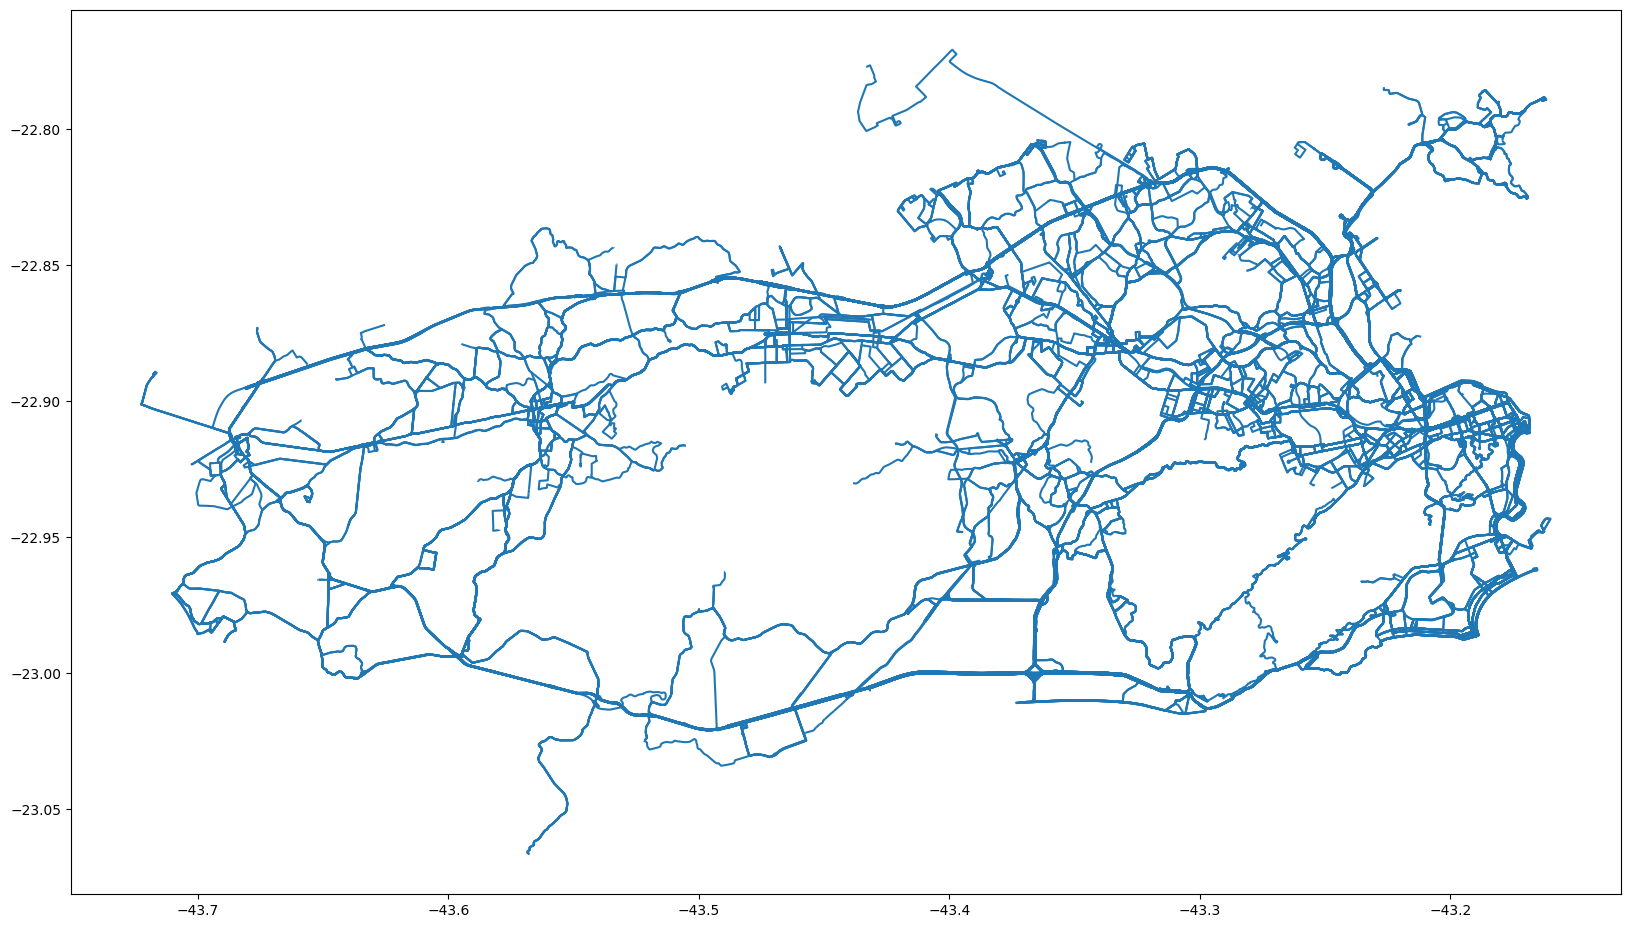

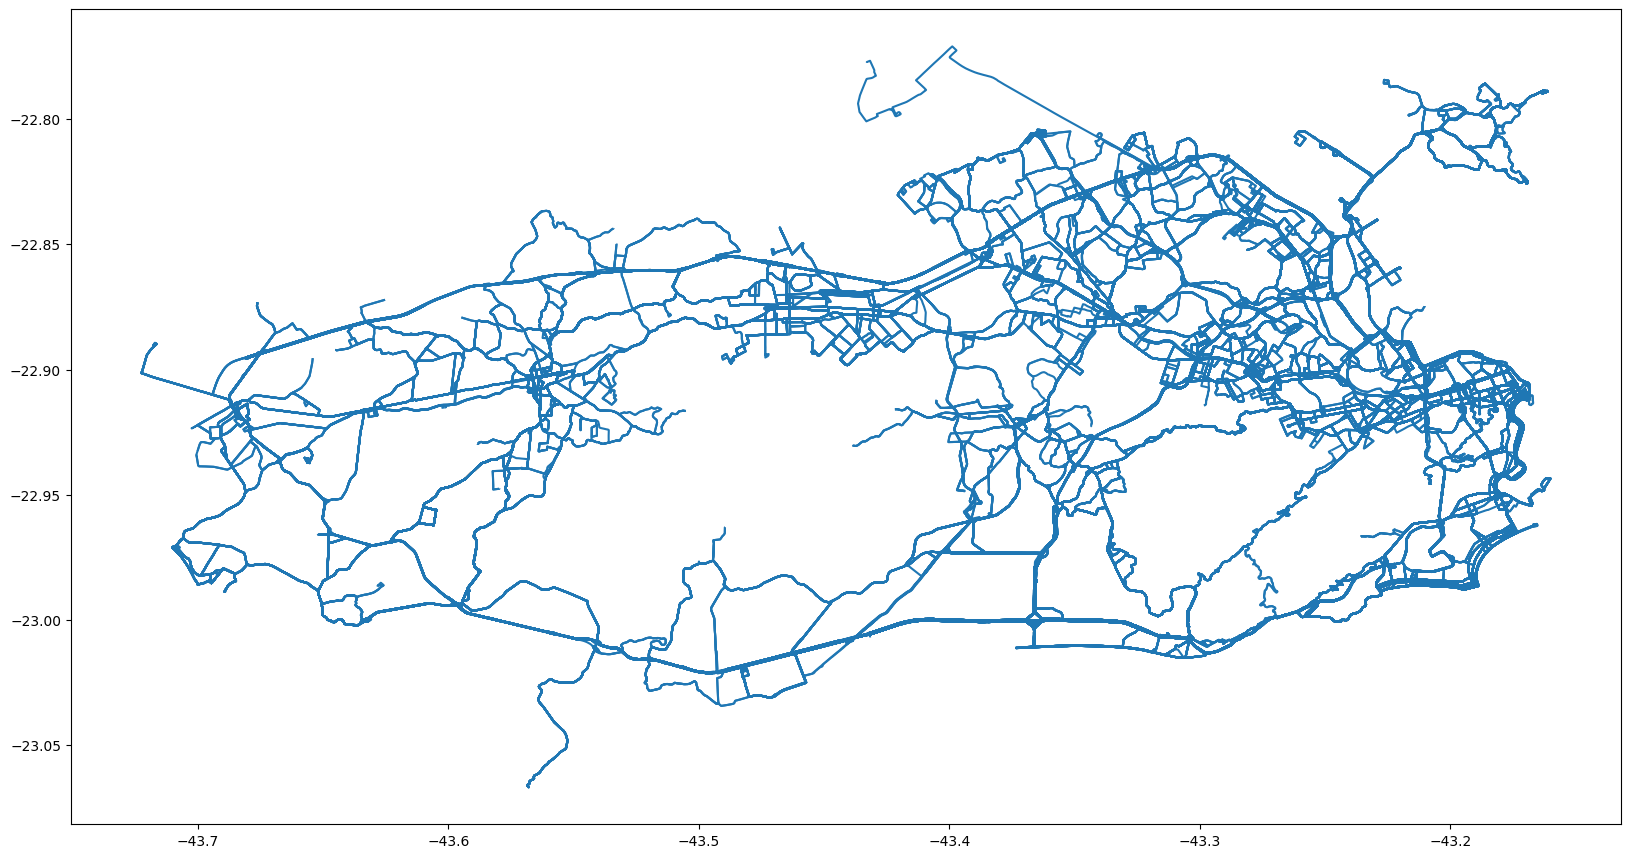

In [39]:
linhasLeve["geometria"].plot(figsize=(20,30))
linhasPesado["shape"].plot(figsize=(20,30))

Como é possível ver a cima, a forte repetição entre as linhas faz com que a versão reduzida do dataset contemple as mesmas ligações entre as regiões. Assim, será usado o dataset leve para a criação do grafo. 

In [40]:
linhas = linhasLeve

## CISPs

In [41]:
cisps = gpd.read_file('../datasets/cisp_geo_data/lm_cisp_bd.shp')
cisps

,cisp,aisp,shape_Leng,shape_Area,AREA_GEO,geometry
0,120,35,1.595433,0.082321,9.375473e+08,"POLYGON ((-42.18687 -22.55548, -42.18733 -22.5..."
1,127,25,0.697487,0.006180,7.027806e+07,"MULTIPOLYGON (((-41.90082 -22.78264, -41.90079..."
2,151,11,1.752923,0.081815,9.334145e+08,"POLYGON ((-42.52555 -22.16087, -42.5006 -22.18..."
3,107,38,1.209676,0.050835,5.805239e+08,"POLYGON ((-43.34665 -22.00375, -43.34603 -22.0..."
4,123,32,2.118860,0.106640,1.216847e+09,"MULTIPOLYGON (((-41.97224 -22.1428, -41.97201 ..."
...,...,...,...,...,...,...
132,76,12,0.338630,0.000828,9.410025e+06,"MULTIPOLYGON (((-43.11375 -22.8646, -43.11358 ..."
133,81,12,0.593683,0.005718,6.495636e+07,"MULTIPOLYGON (((-42.98891 -22.89112, -42.9887 ..."
134,9,2,0.204071,0.000603,6.852825e+06,"POLYGON ((-43.16851 -22.91435, -43.16854 -22.9..."
135,1,5,0.306591,0.000308,3.503511e+06,"MULTIPOLYGON (((-43.17829 -22.89257, -43.1795 ..."


In [42]:
cisps.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 137 entries, 0 to 136
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   cisp        137 non-null    int64   
 1   aisp        137 non-null    int64   
 2   shape_Leng  137 non-null    float64 
 3   shape_Area  137 non-null    float64 
 4   AREA_GEO    137 non-null    float64 
 5   geometry    137 non-null    geometry
dtypes: float64(3), geometry(1), int64(2)
memory usage: 6.6 KB


Como a coluna geometry já está no formato de dado correto, não precisamos fazer nehuma conversão de coluna, basta transformar num dataframe georeferenciado

In [43]:
cisps = cisps.drop(["shape_Leng", "shape_Area", "AREA_GEO"], axis=1)

<Axes: >

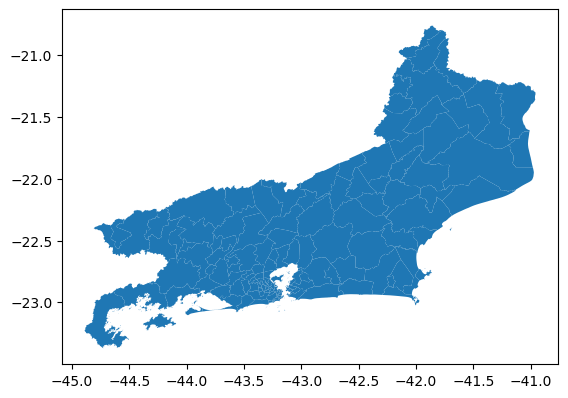

In [44]:
cisps = gpd.GeoDataFrame(cisps, geometry="geometry")
cisps.plot()

# Algorítmo

## Definindo um Grafo

### Criando nó do grafo
Os nós do grafo representam uma cisp. A posição é o centro geométrico da forma, o id é o número da cisp e a periculosidade é o score calculado em scode_linhas

#### Ideia usando classes
Essa ideia vai um pouco contra a filosofia do python, então provavelmente será descartada

In [45]:
class CispNode:
    def __init__(self, id, posicao, periculosidade):
        self.id = id
        self.posicao = posicao
        self.periculosidade = periculosidade

    id = 0
    posicao = (0,0)
    periculosidade = 0

In [46]:
cispNodes = []

In [47]:
iteratableCisps = cisps.reset_index()

for index, cisp in iteratableCisps.iterrows():
    cispNodes.append(CispNode(int(cisp["cisp"]), cisp["geometry"].centroid, 0))


In [48]:
for node in cispNodes:
    print(f'{node.id},\t {node.posicao},  \t {node.periculosidade}')

120,	 POINT (-42.413243196627086 -22.567715754673316),  	 0
127,	 POINT (-41.9500101752408 -22.776069917366815),  	 0
151,	 POINT (-42.50144816375539 -22.319797633078572),  	 0
107,	 POINT (-43.30564407754817 -22.183799832560428),  	 0
123,	 POINT (-41.977294667622964 -22.295770250458563),  	 0
121,	 POINT (-42.144168025497365 -22.482189617363886),  	 0
135,	 POINT (-42.08260909547037 -21.727143654009435),  	 0
155,	 POINT (-42.10238363147984 -21.8835381023256),  	 0
138,	 POINT (-42.136291078817735 -21.25065260314885),  	 0
139,	 POINT (-41.966663131713766 -20.905783844971076),  	 0
144,	 POINT (-41.683699292227445 -21.123232439657915),  	 0
100,	 POINT (-44.25030745014949 -22.367961380297547),  	 0
154,	 POINT (-42.31478368564787 -22.04495394264768),  	 0
130,	 POINT (-41.50424622164376 -22.13198641985968),  	 0
148,	 POINT (-41.55548035115183 -21.488966776332624),  	 0
143,	 POINT (-41.904987825005655 -21.251509906582527),  	 0
140,	 POINT (-41.89681891539761 -20.992366215678132),  

#### Ideia usando dataframes

In [49]:
cispNodesDf = pd.DataFrame(columns=["cisp", "posicao", "score", "geometria"])

In [50]:
iteratableCisps = cisps.reset_index()

for index, cisp in iteratableCisps.iterrows():
    cispNodesDf.loc[index] = [int(cisp["cisp"]), cisp["geometry"].centroid, 0, iteratableCisps["geometry"][index]]

In [51]:
cispNodesDf

,cisp,posicao,score,geometria
0,120,POINT (-42.413243196627086 -22.567715754673316),0,POLYGON ((-42.18687460258013 -22.5554809881563...
1,127,POINT (-41.9500101752408 -22.776069917366815),0,MULTIPOLYGON (((-41.900824352561074 -22.782643...
2,151,POINT (-42.50144816375539 -22.319797633078572),0,POLYGON ((-42.525545352835024 -22.160867586269...
3,107,POINT (-43.30564407754817 -22.183799832560428),0,POLYGON ((-43.346650164372875 -22.003752218889...
4,123,POINT (-41.977294667622964 -22.295770250458563),0,MULTIPOLYGON (((-41.97223535957346 -22.1427977...
...,...,...,...,...
132,76,POINT (-43.120467636289014 -22.886540407187017),0,MULTIPOLYGON (((-43.11375343826984 -22.8646049...
133,81,POINT (-43.031858238839355 -22.934869604197022),0,MULTIPOLYGON (((-42.98891353493099 -22.8911186...
134,9,POINT (-43.18329359943429 -22.932439630204346),0,POLYGON ((-43.16850982656649 -22.9143494629565...
135,1,POINT (-43.146386873617224 -22.835735498997973),0,MULTIPOLYGON (((-43.17828876131654 -22.8925664...


Tem cisp faltando!!!! Por quê????

In [52]:
cispNodesDf["cisp"].max()

np.int64(168)

In [53]:
len(cispNodesDf)

137

In [54]:
cispNodesDf[cispNodesDf["cisp"]==2]

,cisp,posicao,score,geometria


### Definindo o grafo
O grafo será definido como uma matrix de adjacência. As linhas e colunas significam cisps. O valor de 1 indica que essas cisps são ligadas, enquanto 0 diz o contrário. Assim, se `garfo[i][j] == 1`, significa que a cisp i está ligada com a cisp j

In [ ]:
class Grafo:
    def __init__(self, tam):
        self.matrixAdjacencia = [[0 for x in range(tam)] for y in range(tam)]

    matrixAdjacencia = []

    def adicionaAresta(self, i,j):
        self.matrixAdjacencia[i][j] = 1
        self.matrixAdjacencia[j][i] = 1
    
    def tiraAresta(self, i, j):
        self.matrixAdjacencia[i][j] = 0
        self.matrixAdjacencia[j][i] = 0

    def getAresta(self, i, j):
        return self.matrixAdjacencia[i][j]

In [88]:
grafo = Grafo(cispNodesDf["cisp"].max())

In [ ]:
# teste dos métodos
print(grafo.getAresta(10,20))
grafo.adicionaAresta(10,20)
print(grafo.getAresta(10,20))
grafo.tiraAresta(10,20)
print(grafo.getAresta(10,20))

0
1
0


## Percorrendo as linhas

In [ ]:
currentCisp = 0
for linha in linhas["geometria"]:
    if linha.type != "MultiLineString": # Resolver depois
        for ponto in linha.coords:
            for index, cisp in cispNodesDf.iterrows():
                if cisp["geometria"].contains(Point(ponto)):
                    print("わーい")

/tmp/ipykernel_4055/3293744181.py:3: ShapelyDeprecationWarning: The 'type' attribute is deprecated, and will be removed in the future. You can use the 'geom_type' attribute instead.
  if linha.type != "MultiLineString": # Resolver depois


Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow
Wow


KeyboardInterrupt: 